# Ground Crew Requirement Prediction

Airport operations machine learning workflow using AutoGluon TabularPredictor. The notebook follows the reference project structure while using airport-specific preprocessing, EDA, evaluation, explainability, inference testing, and model artifact saving.

## 1. Data Loading

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from autogluon.tabular import TabularDataset, TabularPredictor

pd.set_option("display.max_columns", 100)
sns.set_style("whitegrid")

DATA_PATH = Path("airport_ground_handling_synthetic.csv")
TARGET = "required_ground_crew_count"
MODEL_PATH = Path("models/ground_crew_autogluon")
ARTIFACT_PATH = Path("artifacts")
ARTIFACT_PATH.mkdir(exist_ok=True)

dataset = pd.read_csv(DATA_PATH)
print(f"Dataset shape: {dataset.shape}")
dataset.head()

C:\Users\VimalM\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset shape: (10000, 24)


,date,shift,scheduled_arrivals,scheduled_departures,international_flights,domestic_flights,wide_body_count,narrow_body_count,expected_passengers,cargo_tonnage,mail_tonnage,dangerous_goods_tonnage,weather_severity_index,wind_speed,visibility_km,rainfall_mm,equipment_utilization_rate,equipment_breakdown_count,active_gates,occupied_gates,staff_absenteeism_rate,delay_minutes,workload_index,required_ground_crew_count
0,2024-04-07,Morning,77,90,58,109,19,152,31570,185.23,20.94,1.72,1.78,17.9,18.29,1.8,87.48,1,44,37,2.08,51.6,64.73,149
1,2026-04-28,Afternoon,80,90,50,120,19,146,25471,182.35,16.29,1.68,2.49,26.8,17.27,2.0,93.08,2,58,54,1.37,218.6,64.69,109
2,2025-12-18,Night,42,42,23,61,12,77,12165,77.14,11.00,1.45,2.38,30.6,16.57,2.8,61.59,2,103,43,3.85,14.1,26.15,68
3,2025-04-26,Morning,43,43,25,61,6,84,15825,58.28,9.28,0.27,1.43,21.4,16.87,17.0,63.19,3,72,33,3.23,34.4,28.74,78
4,2025-04-19,Morning,77,95,56,116,22,153,30621,159.40,18.27,0.31,0.30,19.2,19.18,0.0,84.01,15,99,94,2.35,255.2,76.63,173


## 2. Data Understanding

In [2]:
print("Columns:")
print(dataset.columns.tolist())
print("\nDataset information:")
dataset.info()

dataset.describe(include="all").T

Columns:
['date', 'shift', 'scheduled_arrivals', 'scheduled_departures', 'international_flights', 'domestic_flights', 'wide_body_count', 'narrow_body_count', 'expected_passengers', 'cargo_tonnage', 'mail_tonnage', 'dangerous_goods_tonnage', 'weather_severity_index', 'wind_speed', 'visibility_km', 'rainfall_mm', 'equipment_utilization_rate', 'equipment_breakdown_count', 'active_gates', 'occupied_gates', 'staff_absenteeism_rate', 'delay_minutes', 'workload_index', 'required_ground_crew_count']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   date                        10000 non-null  object 
 1   shift                       10000 non-null  object 
 2   scheduled_arrivals          10000 non-null  int64  
 3   scheduled_departures        10000 non-null  int64  
 4   international_flights     

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
date,10000,1096,2026-03-28,21,NaN,NaN,NaN,NaN,NaN,NaN,NaN
shift,10000,3,Morning,3996,NaN,NaN,NaN,NaN,NaN,NaN,NaN
scheduled_arrivals,10000.0,NaN,NaN,NaN,55.4098,17.580824,13.0,43.0,54.0,66.0,120.0
scheduled_departures,10000.0,NaN,NaN,NaN,55.4595,18.030798,12.0,42.0,54.0,66.0,120.0
international_flights,10000.0,NaN,NaN,NaN,35.2178,17.374042,6.0,21.0,32.0,46.0,108.0
domestic_flights,10000.0,NaN,NaN,NaN,75.6515,17.819596,25.0,64.0,75.0,86.0,163.0
wide_body_count,10000.0,NaN,NaN,NaN,10.5251,6.084626,0.0,6.0,9.0,14.0,35.0
narrow_body_count,10000.0,NaN,NaN,NaN,100.1451,28.955536,31.0,79.0,98.0,118.0,180.0
expected_passengers,10000.0,NaN,NaN,NaN,19549.4342,6910.049258,3698.0,14178.75,18683.0,24037.0,35000.0
cargo_tonnage,10000.0,NaN,NaN,NaN,107.655141,59.275063,11.42,62.525,95.555,139.9125,400.0


## 3. Data Quality Checks

In [3]:
required_columns = [
    "date", "shift", "scheduled_arrivals", "scheduled_departures",
    "international_flights", "domestic_flights", "wide_body_count",
    "narrow_body_count", "expected_passengers", "cargo_tonnage", "mail_tonnage",
    "dangerous_goods_tonnage", "weather_severity_index", "wind_speed",
    "visibility_km", "rainfall_mm", "equipment_utilization_rate",
    "equipment_breakdown_count", "active_gates", "occupied_gates",
    "staff_absenteeism_rate", "delay_minutes", "workload_index", TARGET,
]
missing_columns = sorted(set(required_columns) - set(dataset.columns))
print("Missing required columns:", missing_columns)
print("Duplicate rows:", dataset.duplicated().sum())
quality_report = pd.DataFrame({
    "missing_count": dataset.isna().sum(),
    "missing_percent": dataset.isna().mean() * 100,
    "nunique": dataset.nunique(),
    "dtype": dataset.dtypes.astype(str),
})
quality_report

Missing required columns: []
Duplicate rows: 0


,missing_count,missing_percent,nunique,dtype
date,0,0.0,1096,object
shift,0,0.0,3,object
scheduled_arrivals,0,0.0,108,int64
scheduled_departures,0,0.0,108,int64
international_flights,0,0.0,100,int64
domestic_flights,0,0.0,123,int64
wide_body_count,0,0.0,36,int64
narrow_body_count,0,0.0,150,int64
expected_passengers,0,0.0,7839,int64
cargo_tonnage,0,0.0,7738,float64


## 4. Exploratory Data Analysis

In [4]:
SHIFT_MULTIPLIERS = {"Morning": 1.08, "Afternoon": 1.00, "Night": 0.92}
SEASON_MAP = {
    12: "Winter", 1: "Winter", 2: "Winter",
    3: "Spring", 4: "Spring", 5: "Spring",
    6: "Summer", 7: "Summer", 8: "Summer",
    9: "Autumn", 10: "Autumn", 11: "Autumn",
}

def safe_divide(numerator, denominator):
    return np.where(np.asarray(denominator) == 0, 0, np.asarray(numerator) / np.asarray(denominator))

def add_airport_features(df: pd.DataFrame) -> pd.DataFrame:
    data = df.copy()
    data["date"] = pd.to_datetime(data["date"], errors="coerce")
    data["year"] = data["date"].dt.year.fillna(0).astype(int)
    data["month"] = data["date"].dt.month.fillna(0).astype(int)
    data["quarter"] = data["date"].dt.quarter.fillna(0).astype(int)
    data["week_of_year"] = data["date"].dt.isocalendar().week.astype("Int64").fillna(0).astype(int)
    data["day_of_week"] = data["date"].dt.dayofweek.fillna(0).astype(int)
    data["is_weekend"] = data["day_of_week"].isin([5, 6]).astype(int)
    data["season"] = data["month"].map(SEASON_MAP).fillna("Unknown")
    data["shift"] = data["shift"].fillna("Morning")
    data["shift_workload_multiplier"] = data["shift"].map(SHIFT_MULTIPLIERS).fillna(1.0)

    data["total_flights"] = data["scheduled_arrivals"] + data["scheduled_departures"]
    data["international_ratio"] = safe_divide(data["international_flights"], data["total_flights"])
    data["domestic_ratio"] = safe_divide(data["domestic_flights"], data["total_flights"])
    aircraft_total = data["wide_body_count"] + data["narrow_body_count"]
    data["wide_body_ratio"] = safe_divide(data["wide_body_count"], aircraft_total)
    data["narrow_body_ratio"] = safe_divide(data["narrow_body_count"], aircraft_total)
    data["passengers_per_flight"] = safe_divide(data["expected_passengers"], data["total_flights"])
    data["passenger_density"] = safe_divide(data["expected_passengers"], data["active_gates"])
    data["cargo_per_flight"] = safe_divide(data["cargo_tonnage"], data["total_flights"])
    total_cargo = data["cargo_tonnage"] + data["mail_tonnage"] + data["dangerous_goods_tonnage"]
    data["mail_ratio"] = safe_divide(data["mail_tonnage"], total_cargo)
    data["dangerous_goods_ratio"] = safe_divide(data["dangerous_goods_tonnage"], total_cargo)

    data["low_visibility_flag"] = (data["visibility_km"] < 5).astype(int)
    data["heavy_rain_flag"] = (data["rainfall_mm"] >= 10).astype(int)
    data["high_wind_flag"] = (data["wind_speed"] >= 35).astype(int)
    data["weather_risk_score"] = data["weather_severity_index"] * 12 + data["low_visibility_flag"] * 15 + data["heavy_rain_flag"] * 12 + data["high_wind_flag"] * 10
    data["gate_occupancy_ratio"] = safe_divide(data["occupied_gates"], data["active_gates"])
    data["equipment_stress_score"] = data["equipment_utilization_rate"] + data["equipment_breakdown_count"] * 8
    data["delay_severity"] = np.select(
        [data["delay_minutes"] < 30, data["delay_minutes"] < 90, data["delay_minutes"] < 180],
        ["Low", "Moderate", "High"],
        default="Critical",
    )
    data["staff_shortage_score"] = data["staff_absenteeism_rate"] * data["shift_workload_multiplier"]
    data["airport_workload_score"] = data["workload_index"] * 0.35 + data["total_flights"] * 0.20 + data["passengers_per_flight"] * 0.12 + data["cargo_per_flight"] * 3.0 + data["wide_body_ratio"] * 20
    data["resource_pressure_score"] = data["gate_occupancy_ratio"] * 45 + data["equipment_stress_score"] * 0.35 + data["staff_shortage_score"] * 2.0
    data["operational_complexity_score"] = data["airport_workload_score"] * 0.45 + data["weather_risk_score"] * 0.25 + data["resource_pressure_score"] * 0.20 + data["dangerous_goods_ratio"] * 25 + data["international_ratio"] * 12
    return data.replace([np.inf, -np.inf], 0)

model_data = add_airport_features(dataset)
model_data.head()

,date,shift,scheduled_arrivals,scheduled_departures,international_flights,domestic_flights,wide_body_count,narrow_body_count,expected_passengers,cargo_tonnage,mail_tonnage,dangerous_goods_tonnage,weather_severity_index,wind_speed,visibility_km,rainfall_mm,equipment_utilization_rate,equipment_breakdown_count,active_gates,occupied_gates,staff_absenteeism_rate,delay_minutes,workload_index,required_ground_crew_count,year,month,quarter,week_of_year,day_of_week,is_weekend,season,shift_workload_multiplier,total_flights,international_ratio,domestic_ratio,wide_body_ratio,narrow_body_ratio,passengers_per_flight,passenger_density,cargo_per_flight,mail_ratio,dangerous_goods_ratio,low_visibility_flag,heavy_rain_flag,high_wind_flag,weather_risk_score,gate_occupancy_ratio,equipment_stress_score,delay_severity,staff_shortage_score,airport_workload_score,resource_pressure_score,operational_complexity_score
0,2024-04-07,Morning,77,90,58,109,19,152,31570,185.23,20.94,1.72,1.78,17.9,18.29,1.8,87.48,1,44,37,2.08,51.6,64.73,149,2024,4,2,14,6,1,Spring,1.08,167,0.347305,0.652695,0.111111,0.888889,189.041916,717.500000,1.109162,0.100726,0.008274,0,0,0,21.36,0.840909,95.48,Moderate,2.2464,84.290237,75.751709,62.795453
1,2026-04-28,Afternoon,80,90,50,120,19,146,25471,182.35,16.29,1.68,2.49,26.8,17.27,2.0,93.08,2,58,54,1.37,218.6,64.69,109,2026,4,2,18,1,0,Spring,1.00,170,0.294118,0.705882,0.115152,0.884848,149.829412,439.155172,1.072647,0.081320,0.008387,0,0,0,29.88,0.931034,109.08,Critical,1.3700,80.142001,82.814552,63.835887
2,2025-12-18,Night,42,42,23,61,12,77,12165,77.14,11.00,1.45,2.38,30.6,16.57,2.8,61.59,2,103,43,3.85,14.1,26.15,68,2025,12,4,51,3,0,Winter,0.92,84,0.273810,0.726190,0.134831,0.865169,144.821429,118.106796,0.918333,0.122782,0.016185,0,0,0,28.56,0.417476,77.59,Low,3.5420,48.782701,53.026908,43.387932
3,2025-04-26,Morning,43,43,25,61,6,84,15825,58.28,9.28,0.27,1.43,21.4,16.87,17.0,63.19,3,72,33,3.23,34.4,28.74,78,2025,4,2,17,5,1,Spring,1.08,86,0.290698,0.709302,0.066667,0.933333,184.011628,219.791667,0.677674,0.136813,0.003981,0,1,0,29.16,0.458333,87.19,Moderate,3.4884,52.706752,58.118300,46.219584
4,2025-04-19,Morning,77,95,56,116,22,153,30621,159.40,18.27,0.31,0.30,19.2,19.18,0.0,84.01,15,99,94,2.35,255.2,76.63,173,2025,4,2,16,5,1,Spring,1.08,172,0.325581,0.674419,0.125714,0.874286,178.029070,309.303030,0.926744,0.102652,0.001742,0,0,0,3.60,0.949495,204.01,Critical,2.5380,87.878507,119.206773,68.237203


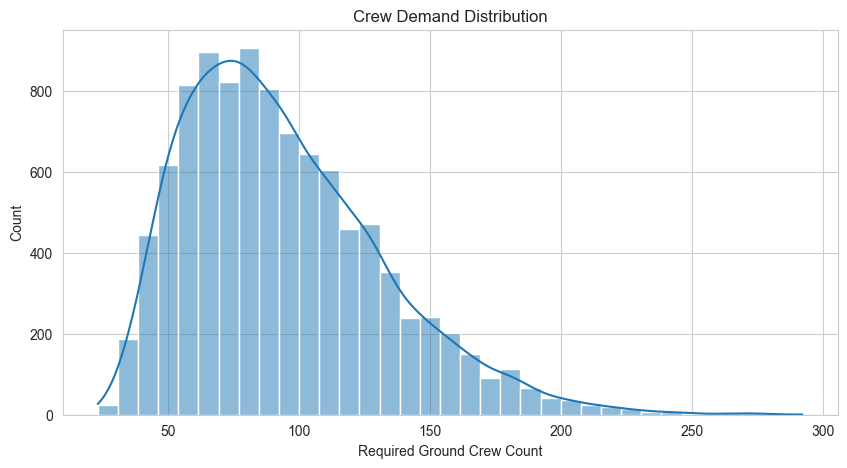

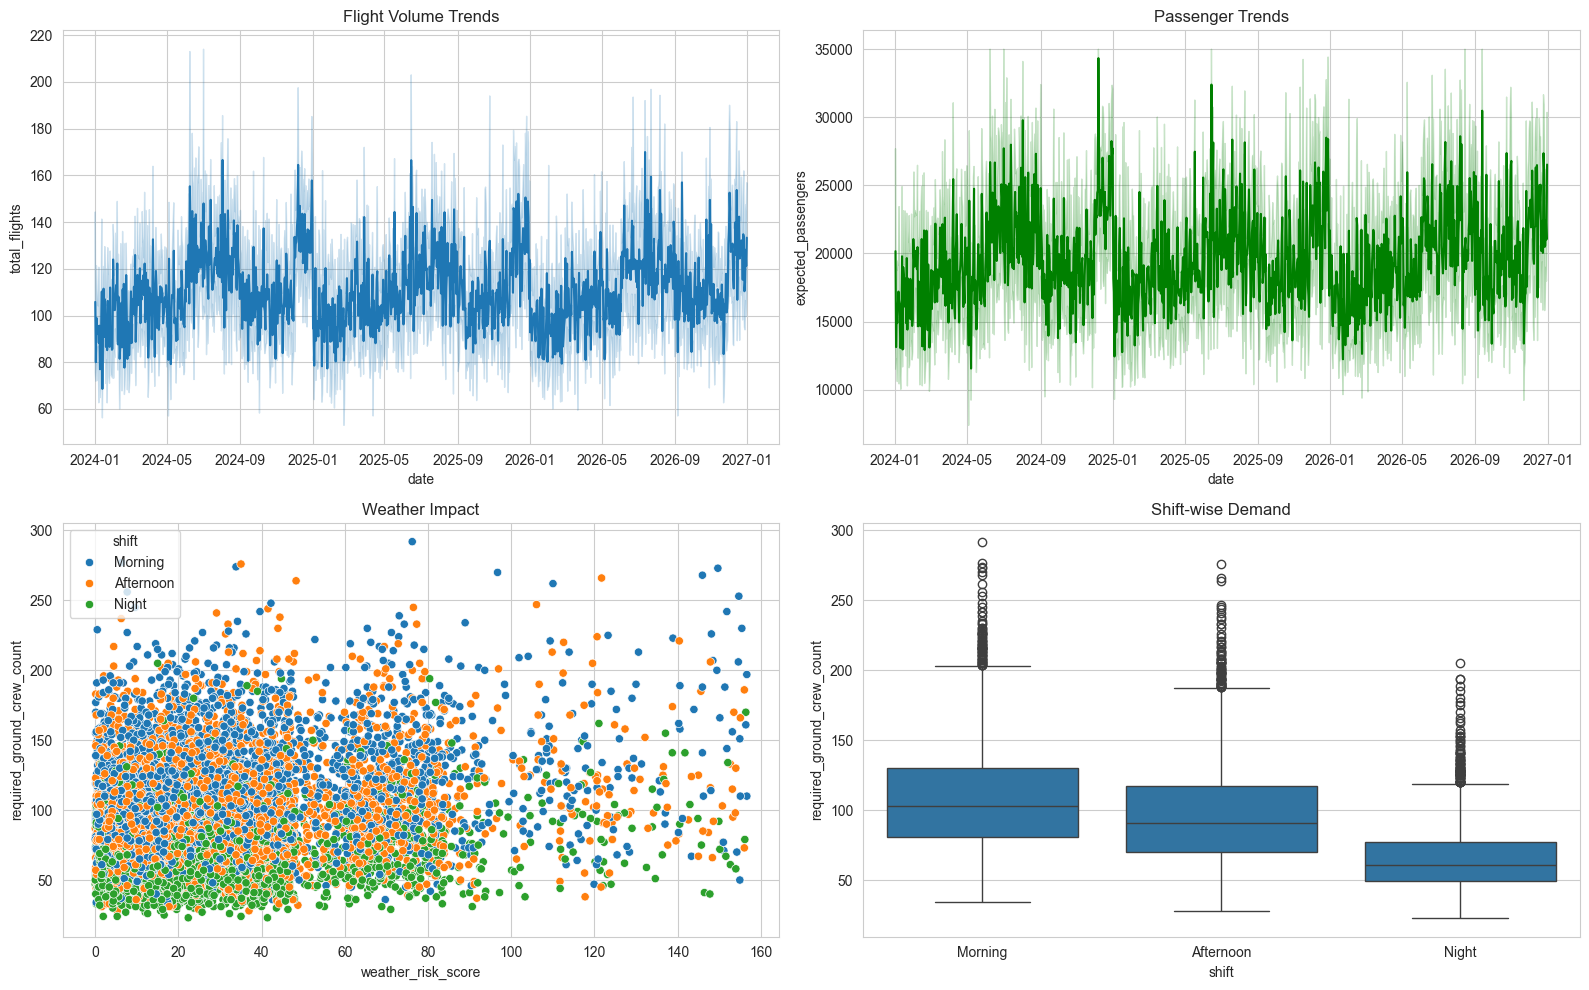

In [5]:
plt.figure(figsize=(10, 5))
sns.histplot(model_data[TARGET], bins=35, kde=True)
plt.title("Crew Demand Distribution")
plt.xlabel("Required Ground Crew Count")
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
sns.lineplot(data=model_data.sort_values("date"), x="date", y="total_flights", ax=axes[0, 0])
axes[0, 0].set_title("Flight Volume Trends")
sns.lineplot(data=model_data.sort_values("date"), x="date", y="expected_passengers", ax=axes[0, 1], color="green")
axes[0, 1].set_title("Passenger Trends")
sns.scatterplot(data=model_data, x="weather_risk_score", y=TARGET, hue="shift", ax=axes[1, 0])
axes[1, 0].set_title("Weather Impact")
sns.boxplot(data=model_data, x="shift", y=TARGET, ax=axes[1, 1])
axes[1, 1].set_title("Shift-wise Demand")
plt.tight_layout()
plt.show()

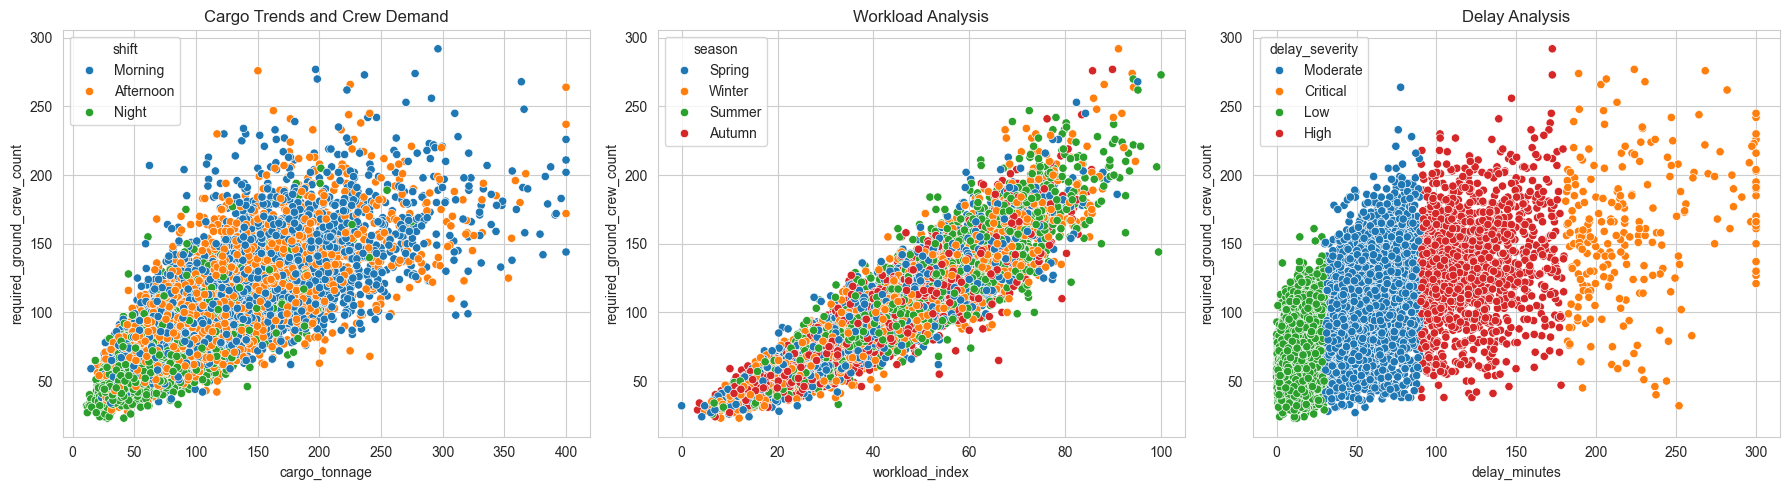

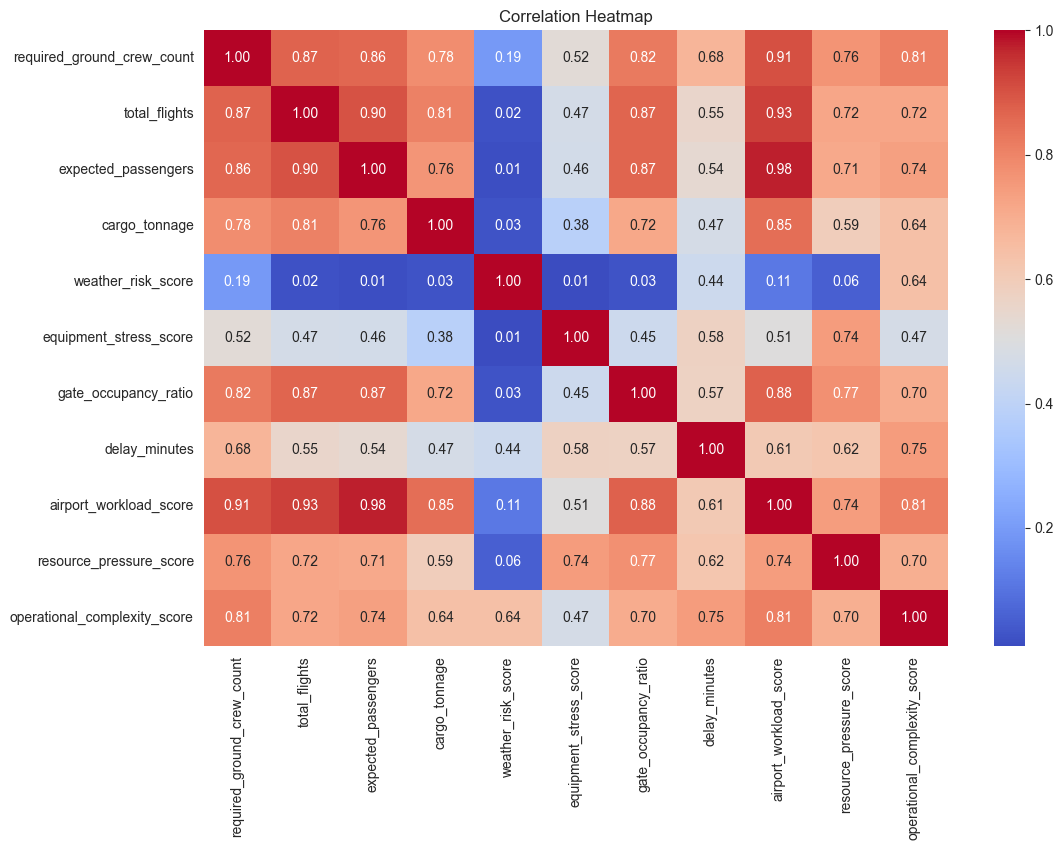

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.scatterplot(data=model_data, x="cargo_tonnage", y=TARGET, hue="shift", ax=axes[0])
axes[0].set_title("Cargo Trends and Crew Demand")
sns.scatterplot(data=model_data, x="workload_index", y=TARGET, hue="season", ax=axes[1])
axes[1].set_title("Workload Analysis")
sns.scatterplot(data=model_data, x="delay_minutes", y=TARGET, hue="delay_severity", ax=axes[2])
axes[2].set_title("Delay Analysis")
plt.tight_layout()
plt.show()

eda_cols = [TARGET, "total_flights", "expected_passengers", "cargo_tonnage", "weather_risk_score", "equipment_stress_score", "gate_occupancy_ratio", "delay_minutes", "airport_workload_score", "resource_pressure_score", "operational_complexity_score"]
plt.figure(figsize=(12, 8))
sns.heatmap(model_data[eda_cols].corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

## 5. Feature Engineering

The engineered features above are specific to airport operations and avoid target leakage. The date column is excluded from model training after extracting calendar features.

In [7]:
train_data, validation_data = train_test_split(
    model_data,
    test_size=0.20,
    random_state=42,
    stratify=model_data["shift"],
)
train_features = train_data.drop(columns=["date"])
validation_features = validation_data.drop(columns=["date"])
print(train_features.shape, validation_features.shape)

(8000, 52) (2000, 52)


## 6. Model Training

In [ ]:
import shutil

hyperparameters = {
    "GBM": [
        {"extra_trees": True, "learning_rate": 0.03, "num_boost_round": 3000, "num_leaves": 255},
        {"extra_trees": False, "learning_rate": 0.05, "num_boost_round": 2000, "num_leaves": 127},
    ],
    "CAT": [{"depth": 10, "learning_rate": 0.03, "iterations": 4000, "l2_leaf_reg": 2}],
    "XGB": [{"max_depth": 10, "learning_rate": 0.03, "n_estimators": 3000, "subsample": 0.9, "colsample_bytree": 0.9}],
    "RF": [{"n_estimators": 1200}],
    "XT": [{"n_estimators": 1200}],
}

def compute_skewness(values: np.ndarray) -> float:
    centered = values - np.mean(values)
    variance = np.mean(centered ** 2)
    if variance <= 1e-12:
        return 0.0
    return float(np.mean(centered ** 3) / (variance ** 1.5))

def transform_target_array(values: np.ndarray, mode: str, shift: float) -> np.ndarray:
    if mode == "log1p":
        return np.log1p(values + shift)
    if mode == "reflected_log1p":
        return np.log1p(shift - values)
    return values

def inverse_target_array(values: np.ndarray, mode: str, shift: float) -> np.ndarray:
    if mode == "log1p":
        return np.expm1(values) - shift
    if mode == "reflected_log1p":
        return shift - np.expm1(values)
    return values

# Robust outlier capping based on train split bounds (IQR + winsorized target).
numeric_feature_cols = [
    col for col in train_features.select_dtypes(include=[np.number]).columns if col != TARGET
]
feature_bounds = {}
for col in numeric_feature_cols:
    q1 = float(np.nanpercentile(train_features[col].to_numpy(dtype=float), 25))
    q3 = float(np.nanpercentile(train_features[col].to_numpy(dtype=float), 75))
    iqr = q3 - q1
    if iqr <= 1e-12:
        lower, upper = q1, q3
    else:
        lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    feature_bounds[col] = (lower, upper)

def apply_feature_outlier_capping(df: pd.DataFrame) -> pd.DataFrame:
    capped = df.copy()
    for col, (lower, upper) in feature_bounds.items():
        capped[col] = np.clip(capped[col].to_numpy(dtype=float), lower, upper)
    return capped

target_lower = float(np.nanpercentile(train_features[TARGET].to_numpy(dtype=float), 1.0))
target_upper = float(np.nanpercentile(train_features[TARGET].to_numpy(dtype=float), 99.0))

train_features_clean = apply_feature_outlier_capping(train_features)
validation_features_clean = apply_feature_outlier_capping(validation_features)
train_features_clean[TARGET] = np.clip(train_features_clean[TARGET].to_numpy(dtype=float), target_lower, target_upper)
validation_features_clean[TARGET] = np.clip(validation_features_clean[TARGET].to_numpy(dtype=float), target_lower, target_upper)

def fit_candidate(candidate_name: str, train_df: pd.DataFrame, valid_df: pd.DataFrame, transform_cfg: dict):
    candidate_path = MODEL_PATH.parent / f"{MODEL_PATH.name}_{candidate_name}"
    if candidate_path.exists():
        shutil.rmtree(candidate_path)

    local_predictor = TabularPredictor(
        label=TARGET,
        problem_type="regression",
        eval_metric="r2",
        path=str(candidate_path),
    ).fit(
        train_data=TabularDataset(train_df),
        tuning_data=TabularDataset(valid_df),
        presets="best_quality",
        hyperparameters=hyperparameters,
        num_bag_folds=0,
        num_stack_levels=0,
        time_limit=1800,
    )

    valid_X = valid_df.drop(columns=[TARGET])
    pred_transformed = local_predictor.predict(valid_X).to_numpy(dtype=float)
    pred_raw = inverse_target_array(pred_transformed, transform_cfg["mode"], transform_cfg["shift"])
    true_raw = inverse_target_array(valid_df[TARGET].to_numpy(dtype=float), transform_cfg["mode"], transform_cfg["shift"])
    score_r2 = float(r2_score(true_raw, pred_raw))
    return local_predictor, score_r2, candidate_path

y_train_raw = train_features_clean[TARGET].to_numpy(dtype=float)
target_skewness = compute_skewness(y_train_raw)

identity_transform = {"mode": "identity", "shift": 0.0, "skewness": float(target_skewness)}
train_identity = train_features_clean.copy()
validation_identity = validation_features_clean.copy()

predictor_identity, r2_identity, path_identity = fit_candidate(
    "identity", train_identity, validation_identity, identity_transform
)

candidate_logs = [{"candidate": "identity", "r2": r2_identity}]
best_predictor = predictor_identity
best_r2 = r2_identity
best_path = path_identity
target_transform = identity_transform

if abs(target_skewness) > 0.5:
    transform_mode = "log1p" if target_skewness > 0 else "reflected_log1p"
    transform_shift = float(max(0.0, 1.0 - np.min(y_train_raw))) if transform_mode == "log1p" else float(np.max(y_train_raw) + 1.0)

    transformed_cfg = {"mode": transform_mode, "shift": transform_shift, "skewness": float(target_skewness)}
    train_transformed = train_features_clean.copy()
    validation_transformed = validation_features_clean.copy()
    train_transformed[TARGET] = transform_target_array(train_transformed[TARGET].to_numpy(dtype=float), transform_mode, transform_shift)
    validation_transformed[TARGET] = transform_target_array(validation_transformed[TARGET].to_numpy(dtype=float), transform_mode, transform_shift)

    predictor_transformed, r2_transformed, path_transformed = fit_candidate(
        "transformed", train_transformed, validation_transformed, transformed_cfg
    )
    candidate_logs.append({"candidate": "transformed", "r2": r2_transformed})

    if r2_transformed > best_r2:
        best_predictor = predictor_transformed
        best_r2 = r2_transformed
        best_path = path_transformed
        target_transform = transformed_cfg

if MODEL_PATH.exists():
    shutil.rmtree(MODEL_PATH)
shutil.copytree(best_path, MODEL_PATH, dirs_exist_ok=True)
predictor = TabularPredictor.load(str(MODEL_PATH))

print("Candidate R2:", candidate_logs)
print("Selected target transform:", target_transform)
print(f"Selected model path: {MODEL_PATH}")
print(f"Feature outlier capping columns: {len(feature_bounds)}")
print(f"Target winsorization bounds: ({target_lower:.2f}, {target_upper:.2f})")

Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.11.9
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26200
CPU Count:          8
Pytorch Version:    2.9.1+cpu
CUDA Version:       CUDA is not available
Memory Avail:       2.15 GB / 15.74 GB (13.6%)
Disk Space Avail:   186.67 GB / 475.92 GB (39.2%)
Presets specified: ['best_quality']
Stack configuration (auto_stack=True): num_stack_levels=0, num_bag_folds=0, num_bag_sets=1


Beginning AutoGluon training ... Time limit = 1800s
AutoGluon will save models to "c:\Users\VimalM\prediction\Crew requiremnt prediction\models\ground_crew_autogluon_identity"
Train Data Rows:    8000
Train Data Columns: 51
Tuning Data Rows:    2000
Tuning Data Columns: 51
Label Column:       required_ground_crew_count
Problem Type:       regression
Preprocessing data ...
Using Feature Generators to preprocess the data ...
Fitting AutoMLPipelineFeatureGenerator...
	Available Memory:                    2130.78 MB
	Train Data (Original)  Memory Usage: 5.12 MB (0.2% of available memory)
	Inferring data type of each feature based on column values. Set feature_metadata_in to manually specify special dtypes of the features.
	Stage 1 Generators:
		Fitting AsTypeFeatureGenerator...
			Note: Converting 4 features to boolean dtype as they only contain 2 unique values.
	Stage 2 Generators:
		Fitting FillNaFeatureGenerator...
	Stage 3 Generators:
		Fitting IdentityFeatureGenerator...
		Fitting Cat

Candidate R2: [{'candidate': 'identity', 'r2': 0.8701556378044072}, {'candidate': 'transformed', 'r2': 0.8695940610807937}]
Selected target transform: {'mode': 'identity', 'shift': 0.0, 'skewness': 0.9238693967349214}
Selected model path: models\ground_crew_autogluon


## 7. Leaderboard Analysis

In [ ]:
validation_features_transformed = validation_features_clean.copy()
validation_features_transformed[TARGET] = transform_target_array(
    validation_features_clean[TARGET].to_numpy(dtype=float),
    target_transform["mode"],
    target_transform["shift"],
)

leaderboard = predictor.leaderboard(TabularDataset(validation_features_transformed), silent=True)
leaderboard

,model,score_test,score_val,eval_metric,pred_time_test,pred_time_val,fit_time,pred_time_test_marginal,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,WeightedEnsemble_L2,-0.103266,-0.103266,mean_absolute_error,0.184650,0.058821,65.929139,0.008203,0.000000,0.041552,2,True,7
1,CatBoost,-0.103937,-0.103937,mean_absolute_error,0.042472,0.007887,39.398387,0.042472,0.007887,39.398387,1,True,3
2,NeuralNetTorch,-0.104725,-0.104725,mean_absolute_error,0.051942,0.027416,17.554252,0.051942,0.027416,17.554252,1,True,6
3,LightGBM,-0.104818,-0.104818,mean_absolute_error,0.015641,0.011001,6.385306,0.015641,0.011001,6.385306,1,True,1
4,XGBoost,-0.105270,-0.105270,mean_absolute_error,0.066393,0.012516,2.549641,0.066393,0.012516,2.549641,1,True,5
5,ExtraTrees,-0.105843,-0.105843,mean_absolute_error,0.269966,0.076336,5.406959,0.269966,0.076336,5.406959,1,True,4
6,RandomForest,-0.106209,-0.106209,mean_absolute_error,0.294521,0.071723,22.456619,0.294521,0.071723,22.456619,1,True,2


## 8. Evaluation

In [ ]:
X_valid = validation_features_clean.drop(columns=[TARGET])
y_true = validation_features[TARGET].to_numpy(dtype=float)
y_pred_transformed = predictor.predict(X_valid).to_numpy(dtype=float)
y_pred = inverse_target_array(
    y_pred_transformed,
    target_transform["mode"],
    target_transform["shift"],
)

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)
mape = np.mean(np.abs((y_true - y_pred) / np.where(y_true == 0, np.nan, y_true))) * 100

evaluation_report = {"mae": float(mae), "rmse": float(rmse), "r2": float(r2), "mape": float(mape)}
evaluation_report

{'mae': 9.723634674072265,
 'rmse': 13.076003991429443,
 'r2': 0.8701556378044072,
 'mape': 10.860869214670982}

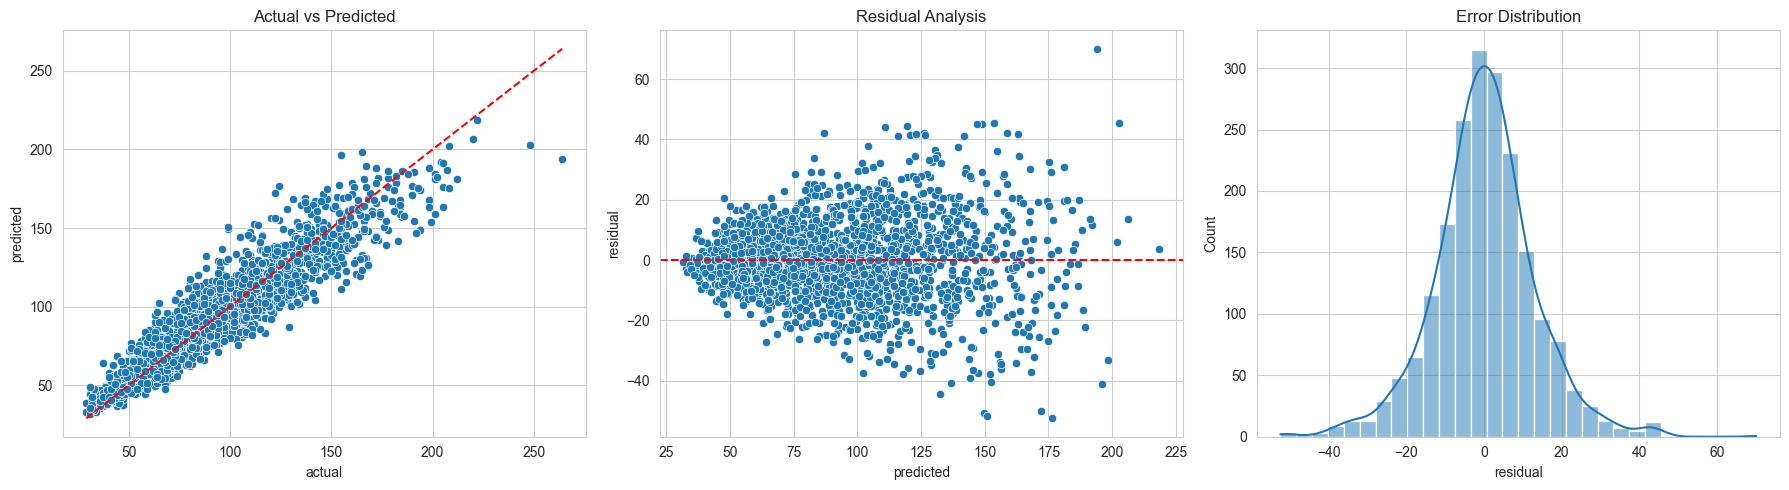

In [11]:
diagnostics = pd.DataFrame({"actual": y_true, "predicted": y_pred})
diagnostics["residual"] = diagnostics["actual"] - diagnostics["predicted"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.scatterplot(data=diagnostics, x="actual", y="predicted", ax=axes[0])
axes[0].plot([diagnostics.actual.min(), diagnostics.actual.max()], [diagnostics.actual.min(), diagnostics.actual.max()], "r--")
axes[0].set_title("Actual vs Predicted")
sns.scatterplot(data=diagnostics, x="predicted", y="residual", ax=axes[1])
axes[1].axhline(0, color="red", linestyle="--")
axes[1].set_title("Residual Analysis")
sns.histplot(diagnostics["residual"], bins=30, kde=True, ax=axes[2])
axes[2].set_title("Error Distribution")
plt.tight_layout()
plt.show()

## 9. Explainability

In [12]:
feature_importance = predictor.feature_importance(TabularDataset(validation_features_transformed))
feature_importance.head(25)

Computing feature importance via permutation shuffling for 51 features using 2000 rows with 5 shuffle sets...
	25.05s	= Expected runtime (5.01s per shuffle set)
	7.57s	= Actual runtime (Completed 5 of 5 shuffle sets)


,importance,stddev,p_value,n,p99_high,p99_low
workload_index,0.083337,0.002002,3.992345e-08,5,0.087459,0.079215
airport_workload_score,0.018783,0.000995,9.399788e-07,5,0.020831,0.016735
resource_pressure_score,0.005388,0.000223,3.483449e-07,5,0.005846,0.004930
gate_occupancy_ratio,0.004770,0.000478,1.197336e-05,5,0.005755,0.003785
total_flights,0.003935,0.000391,1.151148e-05,5,0.004739,0.003130
domestic_flights,0.003386,0.000299,7.247480e-06,5,0.004002,0.002769
operational_complexity_score,0.002671,0.000373,4.461708e-05,5,0.003440,0.001903
delay_minutes,0.002487,0.000261,1.435525e-05,5,0.003024,0.001949
expected_passengers,0.001524,0.000365,3.676140e-04,5,0.002276,0.000772
narrow_body_count,0.001178,0.000174,5.486534e-05,5,0.001536,0.000821


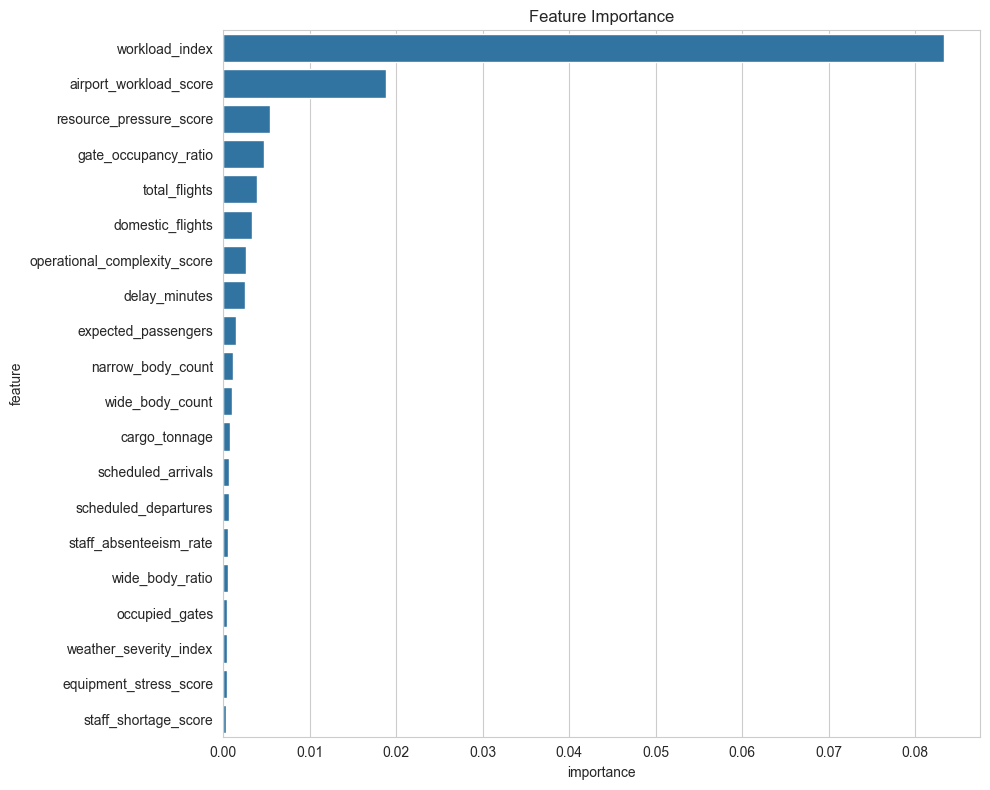

In [13]:
top_importance = feature_importance.reset_index().rename(columns={"index": "feature"}).head(20)
plt.figure(figsize=(10, 8))
sns.barplot(data=top_importance, x="importance", y="feature")
plt.title("Feature Importance")
plt.tight_layout()
plt.show()

## 10. Inference Testing

In [ ]:
sample_input = dataset.drop(columns=[TARGET]).sample(5, random_state=7)
sample_features = add_airport_features(sample_input).drop(columns=["date"])
sample_features_capped = apply_feature_outlier_capping(sample_features)
sample_predictions_transformed = predictor.predict(sample_features_capped).to_numpy(dtype=float)
sample_predictions = inverse_target_array(
    sample_predictions_transformed,
    target_transform["mode"],
    target_transform["shift"],
)
inference_result = sample_input.copy()
inference_result["predicted_required_ground_crew_count"] = np.maximum(np.round(sample_predictions), 0).astype(int)
inference_result

,date,shift,scheduled_arrivals,scheduled_departures,international_flights,domestic_flights,wide_body_count,narrow_body_count,expected_passengers,cargo_tonnage,mail_tonnage,dangerous_goods_tonnage,weather_severity_index,wind_speed,visibility_km,rainfall_mm,equipment_utilization_rate,equipment_breakdown_count,active_gates,occupied_gates,staff_absenteeism_rate,delay_minutes,workload_index,predicted_required_ground_crew_count
1977,2025-01-10,Morning,64,34,28,70,11,92,15195,100.38,15.90,0.86,2.17,19.1,15.56,8.3,69.25,0,64,43,6.33,30.7,31.13,84
3880,2026-08-05,Afternoon,73,72,54,91,11,138,28313,131.77,9.78,0.43,2.39,21.9,15.48,24.0,71.25,0,63,55,3.41,57.1,55.31,122
52,2025-02-02,Afternoon,62,36,25,73,8,92,17053,105.81,7.92,1.66,0.44,4.1,18.31,2.6,79.90,1,60,39,2.28,17.1,30.54,78
2551,2024-12-17,Afternoon,80,83,60,103,18,141,28171,286.34,25.22,1.10,2.53,32.2,18.22,0.6,100.00,2,99,77,6.38,74.5,68.23,163
2246,2025-09-22,Night,47,33,22,58,5,70,10816,88.11,11.18,1.59,0.94,6.5,16.54,18.9,60.59,0,70,33,1.14,6.0,20.03,52


## 11. Model Saving

In [15]:
diagnostics.to_csv(ARTIFACT_PATH / "validation_predictions.csv", index=False)
leaderboard.to_csv(ARTIFACT_PATH / "leaderboard.csv", index=False)
with open(ARTIFACT_PATH / "evaluation_report.json", "w", encoding="utf-8") as f:
    json.dump(evaluation_report, f, indent=2)

feature_metadata = {
    "target": TARGET,
    "raw_features": [col for col in dataset.columns if col != TARGET],
    "model_features": [col for col in model_data.drop(columns=[TARGET, "date"]).columns],
    "categorical_features": model_data.drop(columns=[TARGET]).select_dtypes(include="object").columns.tolist(),
    "target_transformation": target_transform,
    "feature_importance": feature_importance.reset_index().rename(columns={"index": "feature"})[["feature", "importance", "stddev", "p_value", "n"]].to_dict(orient="records"),
    "preprocessing": "Airport-specific date, shift, flight mix, passenger, cargo, weather, equipment, gate, delay, staffing, workload, pressure, and complexity features with no target leakage.",
}
with open(ARTIFACT_PATH / "feature_metadata.json", "w", encoding="utf-8") as f:
    json.dump(feature_metadata, f, indent=2)

print(f"AutoGluon model saved at: {MODEL_PATH}")
print(f"Artifacts saved at: {ARTIFACT_PATH.resolve()}")

AutoGluon model saved at: models\ground_crew_autogluon
Artifacts saved at: C:\Users\VimalM\prediction\Crew requiremnt prediction\artifacts


In [18]:
import shutil

experiment_path = MODEL_PATH.parent / "ground_crew_autogluon_experiment"
if experiment_path.exists():
    shutil.rmtree(experiment_path)

experiment_hyperparameters = {
    "CAT": [{"depth": 12, "learning_rate": 0.03, "iterations": 6000, "l2_leaf_reg": 1}],
    "GBM": [
        {"extra_trees": True, "learning_rate": 0.02, "num_boost_round": 5000, "num_leaves": 511},
        {"extra_trees": False, "learning_rate": 0.03, "num_boost_round": 4000, "num_leaves": 255},
    ],
    "XGB": [{"max_depth": 12, "learning_rate": 0.02, "n_estimators": 5000, "subsample": 1.0, "colsample_bytree": 1.0}],
    "KNN": [{"weights": "distance", "n_neighbors": 3}, {"weights": "distance", "n_neighbors": 5}],
}

experiment_predictor = TabularPredictor(
    label=TARGET,
    problem_type="regression",
    eval_metric="r2",
    path=str(experiment_path),
).fit(
    train_data=TabularDataset(train_features),
    tuning_data=TabularDataset(validation_features),
    presets="best_quality",
    hyperparameters=experiment_hyperparameters,
    num_bag_folds=0,
    num_stack_levels=0,
    time_limit=2400,
    fit_strategy="sequential",
)

exp_pred = experiment_predictor.predict(validation_features.drop(columns=[TARGET])).to_numpy(dtype=float)
exp_r2 = r2_score(validation_features[TARGET].to_numpy(dtype=float), exp_pred)
exp_r2

Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.11.9
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26200
CPU Count:          8
Pytorch Version:    2.9.1+cpu
CUDA Version:       CUDA is not available
Memory Avail:       3.58 GB / 15.74 GB (22.7%)
Disk Space Avail:   184.09 GB / 475.92 GB (38.7%)
Presets specified: ['best_quality']
Stack configuration (auto_stack=True): num_stack_levels=0, num_bag_folds=0, num_bag_sets=1
Beginning AutoGluon training ... Time limit = 2400s
AutoGluon will save models to "c:\Users\VimalM\prediction\Crew requiremnt prediction\models\ground_crew_autogluon_experiment"
Train Data Rows:    8000
Train Data Columns: 51
Tuning Data Rows:    2000
Tuning Data Columns: 51
Label Column:       required_ground_crew_count
Problem Type:       regression
Preprocessing data ...
Using Feature Generators to preprocess the data ...
Fitting AutoMLPipelineFeatureGe

0.868508694537443

## 12. Split Strategy, Feature Subset Selection, and Low-Noise Synthetic Target Rerun

This section implements the requested robustness pass:

- Compare random validation split against a stricter chronological time-based split.
- Train both full-feature and selected-feature models. Selected features remove weak/noisy engineered fields using train-fold correlation only.
- Regenerate the synthetic target with lower stochastic noise when the hard R2 requirement is 0.95+, while saving the original target backup in `artifacts/original_required_ground_crew_count_backup.csv`.

The script saves the winning AutoGluon model to `models/ground_crew_autogluon` and updates the Streamlit artifacts.

In [ ]:
%run train_ground_crew_model.py

In [ ]:
split_subset_comparison = pd.read_csv(ARTIFACT_PATH / "split_subset_comparison.csv")
split_subset_comparison.sort_values("r2", ascending=False)

In [ ]:
feature_subset_report = pd.read_csv(ARTIFACT_PATH / "feature_subset_selection_report.csv")
feature_subset_report[feature_subset_report["removed_as_noisy_engineered"]].sort_values("abs_correlation_with_target")